Loading cleaned dataset...


/tmp/ipykernel_203294/3898887343.py:11: DtypeWarning: Columns (0: vehicle.currentStopSequence, 1: vehicle.congestionLevel) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/bkk_cleaned.csv', dtype={'vehicle.vehicle.licensePlate': str, 'vehicle.trip.tripId': str})


Extracting datetime features...
Dataset shape: (193555, 24)

--- Basic Statistics of Target Variable (Minutes) ---
count    193555.000000
mean          1.670012
std           4.256671
min           0.016667
25%           0.150000
50%           0.416667
75%           1.083333
max          59.900000
Name: minutes_to_next_stop, dtype: float64


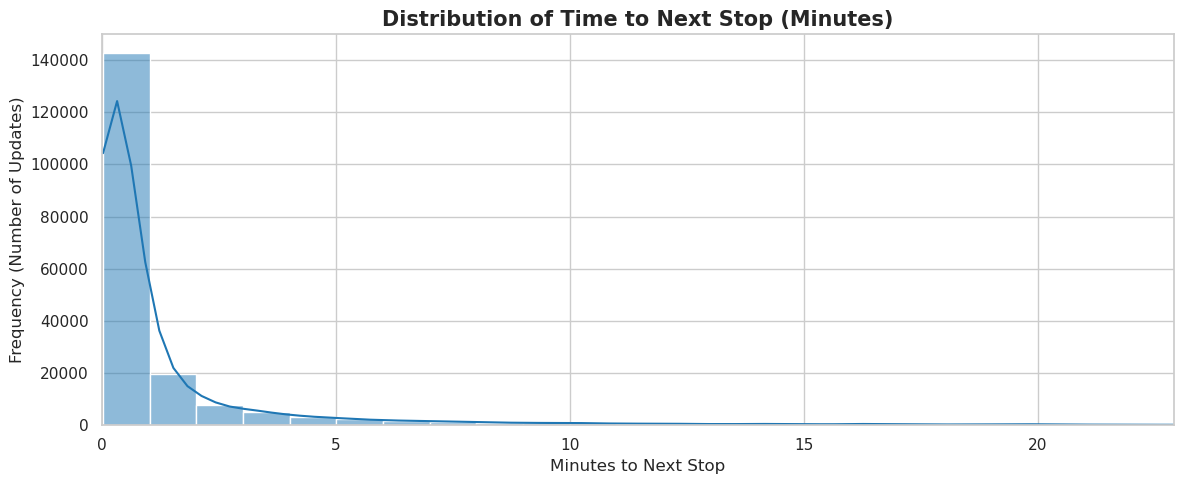

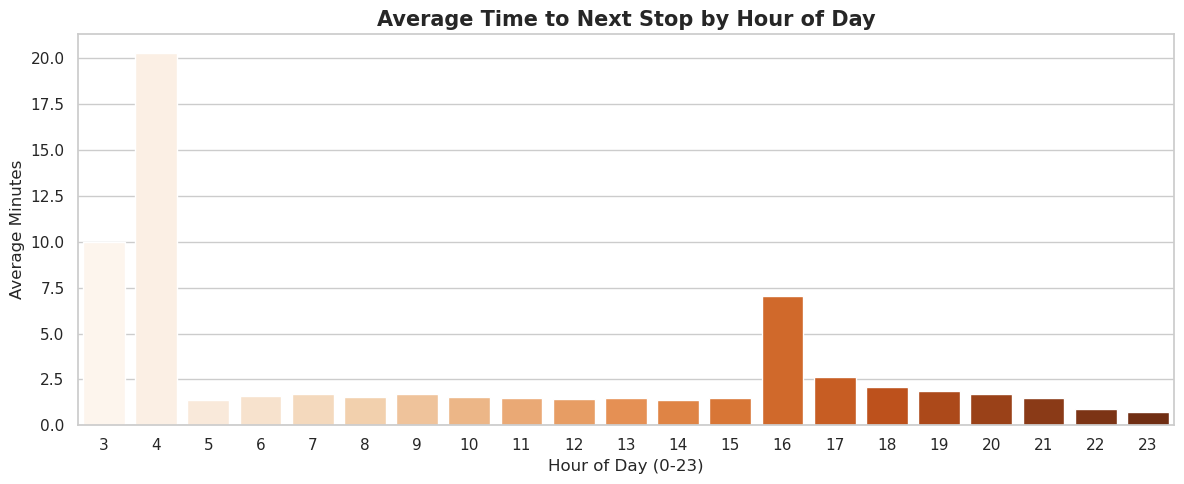

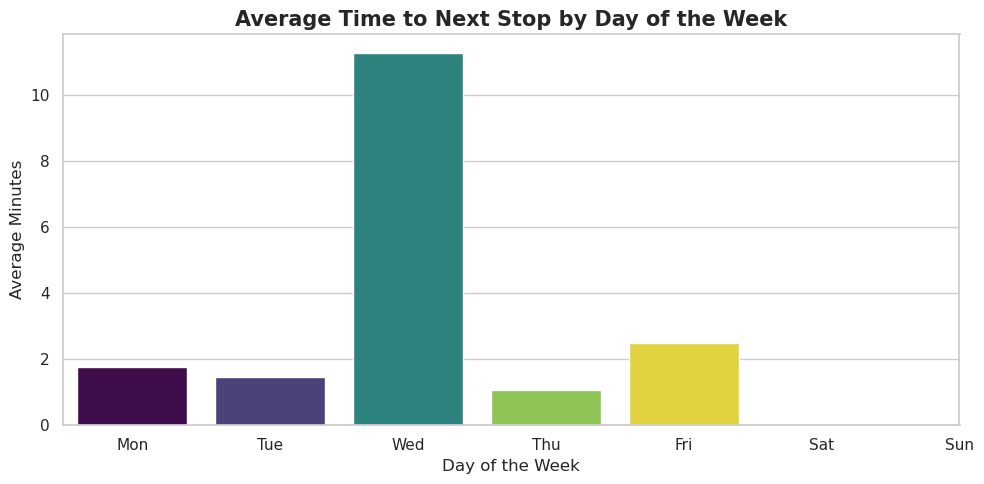

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for the plots
sns.set_theme(style="whitegrid")

print("Loading cleaned dataset...")
# Read the cleaned data
df = pd.read_csv('../data/processed/bkk_cleaned.csv', dtype={'vehicle.vehicle.licensePlate': str, 'vehicle.trip.tripId': str})

# 1. Feature Engineering for EDA
# Convert timestamps to datetime to extract hour, day of week, etc.
print("Extracting datetime features...")
df['vehicle_datetime'] = pd.to_datetime(df['vehicle.timestamp'], unit='s')
df['hour_of_day'] = df['vehicle_datetime'].dt.hour
df['day_of_week'] = df['vehicle_datetime'].dt.dayofweek # 0 = Monday, 6 = Sunday

# Convert seconds to minutes for easier human interpretation
df['minutes_to_next_stop'] = df['seconds_to_next_stop'] / 60.0

print(f"Dataset shape: {df.shape}")
print("\n--- Basic Statistics of Target Variable (Minutes) ---")
print(df['minutes_to_next_stop'].describe())

# ---------------------------------------------------------
# VISUALIZATION 1: Distribution of Wait Times
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
sns.histplot(df['minutes_to_next_stop'], bins=60, kde=True, color='#1f77b4')
plt.title('Distribution of Time to Next Stop (Minutes)', fontsize=15, fontweight='bold')
plt.xlabel('Minutes to Next Stop', fontsize=12)
plt.ylabel('Frequency (Number of Updates)', fontsize=12)
plt.xlim(0, df['minutes_to_next_stop'].quantile(0.99)) # Cut off extreme 1% outliers for a cleaner plot
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# VISUALIZATION 2: Average Wait Time by Hour of Day
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
hourly_avg = df.groupby('hour_of_day')['minutes_to_next_stop'].mean().reset_index()
sns.barplot(data=hourly_avg, x='hour_of_day', y='minutes_to_next_stop', hue='hour_of_day', palette='Oranges', legend=False)
plt.title('Average Time to Next Stop by Hour of Day', fontsize=15, fontweight='bold')
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Average Minutes', fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# VISUALIZATION 3: Wait Time vs. Day of the Week
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
# Map numeric days to names
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_avg = df.groupby('day_of_week')['minutes_to_next_stop'].mean().reset_index()

sns.barplot(data=daily_avg, x='day_of_week', y='minutes_to_next_stop', hue='day_of_week', palette='viridis', legend=False)
plt.title('Average Time to Next Stop by Day of the Week', fontsize=15, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Minutes', fontsize=12)
plt.xticks(ticks=range(7), labels=day_names)
plt.tight_layout()
plt.show()